# Deep Q-Network (DQN) for Atari Breakout

This notebook trains a **Deep Q-Network** agent to play the Atari game Breakout.  
It is based on the original DeepMind paper:

> *Playing Atari with Deep Reinforcement Learning* — Mnih et al. (2013)

---

## How it Works

| Step | What happens |
|------|--------------|
| **Observe** | The agent receives 4 stacked grayscale frames (84×84) as its state |
| **Act** | A CNN maps frames → Q-values; the agent picks the highest-value action |
| **Store** | The transition `(state, action, reward, next_state, done)` goes into a replay buffer |
| **Train** | A random mini-batch from the buffer is used to update the CNN weights |
| **Stabilise** | A frozen **target network** provides stable training targets, updated every N steps |

## Breakout Action Space

| Action | Meaning |
|--------|---------|
| 0 | NOOP |
| 1 | FIRE (launch ball) |
| 2 | RIGHT |
| 3 | LEFT |

## The Bellman Update

The network is trained to satisfy:

$$Q(s, a) \leftarrow r + \gamma \cdot \max_{a'} Q_{\text{target}}(s', a') \cdot (1 - \text{done})$$


In [ ]:
# ── Install dependencies (run once, then comment out) ──────────────────────
!pip install -r requirements.txt
!AutoROM --accept-license


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'
/bin/bash: line 1: AutoROM: command not found


In [1]:
import random
import time
from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
import ale_py
from gymnasium.wrappers import AtariPreprocessing

# Register ALE Atari environments with gymnasium (required in gymnasium >= 0.26)
gym.register_envs(ale_py)

# gymnasium >= 1.0 renamed FrameStack to FrameStackObservation
try:
    from gymnasium.wrappers import FrameStackObservation as FrameStack
except ImportError:
    from gymnasium.wrappers import FrameStack

from tqdm.notebook import trange

print(f'gymnasium version: {gym.__version__}')
print(f'torch version:     {torch.__version__}')
print(f'ale_py version:    {ale_py.__version__}')


gymnasium version: 1.3.0
torch version:     2.12.0+cpu
ale_py version:    0.11.2


In [2]:
# ── Helper: normalise observation shape ────────────────────────────────────
# gymnasium < 1.0  → FrameStack gives shape (4, 84, 84)
# gymnasium >= 1.0 → FrameStackObservation gives shape (84, 84, 4)
# This function always returns (4, 84, 84) float32 in [0, 1].

def obs_to_array(obs) -> np.ndarray:
    arr = np.array(obs, dtype=np.float32) / 255.0
    if arr.ndim == 3 and arr.shape[2] == 4:   # (H, W, 4) → (4, H, W)
        arr = np.transpose(arr, (2, 0, 1))
    return arr


## Hyperparameters

| Parameter | Value | What it controls |
|-----------|-------|------------------|
| `BUFFER_SIZE` | 100 000 | Max transitions stored in replay buffer |
| `BATCH_SIZE` | 32 | Experiences per gradient update |
| `GAMMA` | 0.99 | Discount factor — how much future rewards matter |
| `LEARNING_RATE` | 1e-4 | Adam step size |
| `NUM_FRAMES` | 1 000 000 | Total environment steps (↓ for smoke test) |
| `MIN_REPLAY_SIZE` | 10 000 | Buffer fill-up before training starts |
| `TRAIN_FREQ` | 4 | Train every N environment steps |
| `EPSILON_START` | 1.0 | Start fully random |
| `EPSILON_END` | 0.1 | Minimum exploration rate |
| `EPSILON_DECAY_FRAMES` | 500 000 | Frames over which ε decays linearly |
| `TARGET_UPDATE_FREQ` | 1 000 | Hard-copy policy → target every N steps |


In [3]:
# ── Environment ────────────────────────────────────────────────────────────
ENV_ID = 'ALE/Breakout-v5'

# ── Replay Buffer ──────────────────────────────────────────────────────────
BUFFER_SIZE = 100_000

# ── Training ───────────────────────────────────────────────────────────────
BATCH_SIZE      = 32
GAMMA           = 0.99
LEARNING_RATE   = 1e-4
NUM_FRAMES      = 1_000_000  # set to 50_000 for a quick smoke test
MIN_REPLAY_SIZE = 10_000
TRAIN_FREQ      = 4

# ── Exploration ────────────────────────────────────────────────────────────
EPSILON_START        = 1.0
EPSILON_END          = 0.1
EPSILON_DECAY_FRAMES = 500_000

# ── Target Network ─────────────────────────────────────────────────────────
TARGET_UPDATE_FREQ = 1_000

# ── Checkpointing ──────────────────────────────────────────────────────────
SAVE_FREQ = 250_000
CHECKPOINT_DIR = Path('checkpoints')
CHECKPOINT_DIR.mkdir(exist_ok=True)

# ── Device ─────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU:    {torch.cuda.get_device_name(0)}')


Device: cpu


## Environment & Preprocessing

The raw Atari game runs at **210×160 RGB pixels**. Two wrappers reduce it to something a CNN can learn from:

### `AtariPreprocessing`
- **Grayscale** — colour carries no extra information for Breakout gameplay
- **Resize** — shrinks to 84×84 (standard DQN input size; reduces parameters)
- **Frame skip** — repeats each action for 4 frames; max-pool of last 2 removes flickering sprites
- `scale_obs=False` keeps values as **uint8** (0–255) for memory efficiency

### `FrameStack`
Stacks 4 consecutive frames into a single state of shape **(4, 84, 84)**.  
This gives the network a sense of **motion** — it can infer ball direction and speed from the difference between frames.


In [4]:
def make_env(env_id=ENV_ID, render_mode=None):
    '''Create the Breakout environment with standard DQN preprocessing.'''
    # frameskip=1 disables the ALE's built-in frame skip so AtariPreprocessing
    # can apply its own (avoids "double frame-skip" ValueError in gymnasium >= 1.0)
    env = gym.make(env_id, render_mode=render_mode, frameskip=1)
    env = AtariPreprocessing(env, grayscale_obs=True, scale_obs=False, frame_skip=4)
    env = FrameStack(env, 4)
    return env


# ── Verify shapes ──────────────────────────────────────────────────────────
env_test = make_env()
obs_raw, info = env_test.reset()
obs_array = obs_to_array(obs_raw)          # always (4, 84, 84) float32
obs_uint8 = (obs_array * 255).astype(np.uint8)

print(f'Raw obs shape:    {np.array(obs_raw).shape}')
print(f'Processed shape:  {obs_array.shape}')   # (4, 84, 84)
print(f'Action space:     {env_test.action_space}')
print(f'Actions:          {env_test.unwrapped.get_action_meanings()}')
env_test.close()


Raw obs shape:    (4, 84, 84)
Processed shape:  (4, 84, 84)
Action space:     Discrete(4)
Actions:          ['NOOP', 'FIRE', 'RIGHT', 'LEFT']


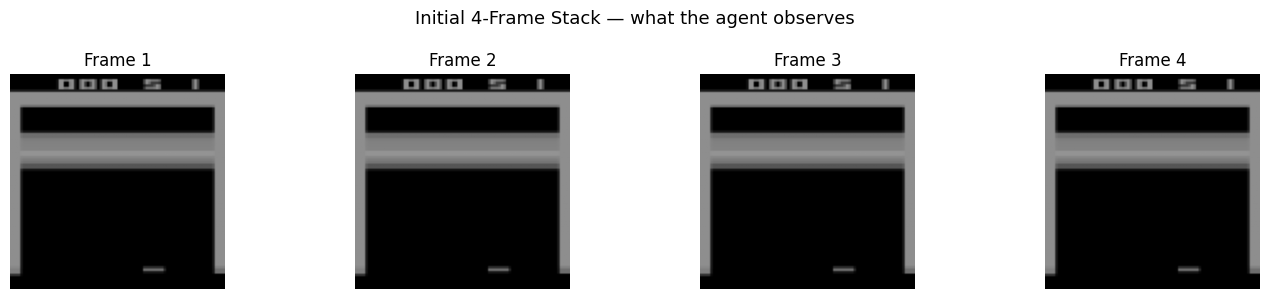

In [5]:
# ── Visualise the 4-frame stack ────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for i, ax in enumerate(axes):
    ax.imshow(obs_uint8[i], cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'Frame {i + 1}')
    ax.axis('off')
fig.suptitle('Initial 4-Frame Stack — what the agent observes', fontsize=13)
plt.tight_layout()
plt.show()


## Experience Replay Buffer

### Why do we need it?
Consecutive game frames are **highly correlated** — training on them in order would cause the network to overfit to recent experience and catastrophically forget earlier knowledge.  
Randomly sampling from a large buffer **breaks these correlations**, making training more like supervised learning.

### Memory Efficiency
A single 84×84 `uint8` frame costs 7 056 bytes.  
Stored as `float32` it would cost **4× more**.  
We store as `uint8` and cast to `float32` only at training time.

### What Gets Stored
Each entry is a tuple `(state, action, reward, next_state, done)` where:
- `state` / `next_state` — shape `(4, 84, 84)` uint8
- `action` — integer in `{0, 1, 2, 3}`
- `reward` — float, **clipped to [−1, +1]** for gradient stability
- `done` — bool (True if episode ended *or* a life was lost)


In [6]:
class ReplayBuffer:
    '''
    Circular buffer storing (state, action, reward, next_state, done) tuples.
    States are stored as uint8 and normalised to float32 on sampling.
    '''

    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action: int, reward: float, next_state, done: bool):
        # Convert using obs_to_array to ensure (4,84,84) shape, then store as uint8
        s  = (obs_to_array(state)      * 255).astype(np.uint8)
        ns = (obs_to_array(next_state) * 255).astype(np.uint8)
        self.buffer.append((s, int(action), float(reward), ns, bool(done)))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states,      dtype=np.float32) / 255.0,
            np.array(actions,     dtype=np.int64),
            np.array(rewards,     dtype=np.float32),
            np.array(next_states, dtype=np.float32) / 255.0,
            np.array(dones,       dtype=np.float32),
        )

    def __len__(self) -> int:
        return len(self.buffer)


## Deep Q-Network Architecture

We use the exact CNN from the original DeepMind DQN paper:

```
Input  (batch, 4, 84, 84)
  │
  ├─ Conv2d(4→32,  8×8, stride 4)  → (batch, 32, 20, 20)
  ├─ ReLU
  ├─ Conv2d(32→64, 4×4, stride 2)  → (batch, 64,  9,  9)
  ├─ ReLU
  ├─ Conv2d(64→64, 3×3, stride 1)  → (batch, 64,  7,  7)
  ├─ ReLU
  ├─ Flatten                        → (batch, 3136)
  ├─ Linear(3136 → 512) + ReLU
  └─ Linear(512  → n_actions)       → (batch, 4)
```

The output is a **Q-value** for every possible action.  
The agent picks `argmax` — the action with the highest predicted future reward.


In [7]:
class DQN(nn.Module):
    '''
    DeepMind DQN convolutional Q-network.
    Input:  (batch, 4, 84, 84)  — 4 stacked grayscale frames
    Output: (batch, n_actions)   — Q-value for each possible action
    '''

    def __init__(self, n_actions: int):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(4,  32, kernel_size=8, stride=4),  # → (32, 20, 20)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),  # → (64,  9,  9)
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),  # → (64,  7,  7)
            nn.ReLU(),
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)
        x = x.view(x.size(0), -1)  # flatten spatial dimensions
        return self.fc(x)


# ── Sanity check ───────────────────────────────────────────────────────────
_net = DQN(n_actions=4)
_x   = torch.zeros(1, 4, 84, 84)
_y   = _net(_x)
print(f'Input shape:  {tuple(_x.shape)}')
print(f'Output shape: {tuple(_y.shape)}')   # should be (1, 4)
print(f'Parameters:   {sum(p.numel() for p in _net.parameters()):,}')
del _net, _x, _y


Input shape:  (1, 4, 84, 84)
Output shape: (1, 4)
Parameters:   1,686,180


## DQN Agent

The agent wraps together:

### 1 — Epsilon-Greedy Exploration
- With probability **ε** → pick a **random** action (explore)
- With probability **1−ε** → pick `argmax Q(s,a)` (exploit)
- ε decays linearly from 1.0 → 0.1 over `EPSILON_DECAY_FRAMES` steps

### 2 — Training Step (Bellman update)
1. Sample a random mini-batch from the replay buffer
2. Compute **current** Q-values with the **policy network**
3. Compute **target** Q-values with the **frozen target network** (no gradient flows here)
4. Minimise Huber loss: `L = smooth_l1(Q_policy, r + γ · max Q_target)`
5. Clip gradients to ‖g‖ ≤ 10 to prevent exploding updates

### 3 — Why Two Networks?
If we used a single network to both *select* and *evaluate* actions, the training target would shift every time we update the weights — like chasing a moving goalpost.  
The **target network** is a frozen copy that only syncs every `TARGET_UPDATE_FREQ` steps, providing stable, consistent targets.


In [8]:
class DQNAgent:
    '''DQN agent with policy/target networks, replay buffer, and epsilon-greedy policy.'''

    def __init__(self, n_actions: int, device: torch.device):
        self.n_actions = n_actions
        self.device    = device
        self.epsilon   = EPSILON_START
        self.losses: list = []

        # Policy network: trained continuously
        self.policy_net = DQN(n_actions).to(device)
        # Target network: frozen copy, updated periodically
        self.target_net = DQN(n_actions).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer     = optim.Adam(self.policy_net.parameters(), lr=LEARNING_RATE)
        self.replay_buffer = ReplayBuffer(BUFFER_SIZE)

    # ── Action selection ──────────────────────────────────────────────────
    def select_action(self, state, frame_count: int) -> int:
        '''Epsilon-greedy with linear epsilon decay.'''
        self.epsilon = max(
            EPSILON_END,
            EPSILON_START - (EPSILON_START - EPSILON_END) * frame_count / EPSILON_DECAY_FRAMES,
        )
        if random.random() < self.epsilon:
            return random.randrange(self.n_actions)

        state_t = torch.from_numpy(obs_to_array(state)).unsqueeze(0).to(self.device)
        with torch.no_grad():
            return self.policy_net(state_t).argmax(dim=1).item()

    # ── Training step ─────────────────────────────────────────────────────
    def train_step(self) -> float:
        '''Sample a mini-batch and perform one Bellman gradient update.'''
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(BATCH_SIZE)

        states_t      = torch.from_numpy(states).to(self.device)
        actions_t     = torch.from_numpy(actions).to(self.device)
        rewards_t     = torch.from_numpy(rewards).to(self.device)
        next_states_t = torch.from_numpy(next_states).to(self.device)
        dones_t       = torch.from_numpy(dones).to(self.device)

        # Q(s, a) — only for the actions that were actually taken
        current_q = self.policy_net(states_t).gather(1, actions_t.unsqueeze(1)).squeeze(1)

        # r + gamma * max_a' Q_target(s', a')   (no gradient through target)
        with torch.no_grad():
            next_q = self.target_net(next_states_t).max(dim=1)[0]
        target_q = rewards_t + GAMMA * next_q * (1.0 - dones_t)

        # Huber loss is less sensitive to large TD errors than MSE
        loss = nn.functional.smooth_l1_loss(current_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 10.0)
        self.optimizer.step()

        loss_val = loss.item()
        self.losses.append(loss_val)
        return loss_val

    # ── Target network update ─────────────────────────────────────────────
    def update_target_network(self):
        '''Hard copy: clone policy weights into target network.'''
        self.target_net.load_state_dict(self.policy_net.state_dict())

    # ── Persistence ───────────────────────────────────────────────────────
    def save(self, path):
        torch.save({
            'policy_net': self.policy_net.state_dict(),
            'target_net': self.target_net.state_dict(),
            'optimizer':  self.optimizer.state_dict(),
            'epsilon':    self.epsilon,
        }, path)
        print(f'Checkpoint saved: {path}')

    def load(self, path):
        ckpt = torch.load(path, map_location=self.device, weights_only=True)
        self.policy_net.load_state_dict(ckpt['policy_net'])
        self.target_net.load_state_dict(ckpt['target_net'])
        self.optimizer.load_state_dict(ckpt['optimizer'])
        self.epsilon = ckpt['epsilon']
        print(f'Checkpoint loaded: {path}')


## Training Loop

### Key Design Decisions

**Reward clipping**  
All rewards are clipped to [−1, +1]. This normalises gradient scale across Atari games that have wildly different score ranges and prevents Q-values from diverging to infinity.

**Life loss as terminal**  
In Breakout, losing a life does not reset the game — it just spawns a new ball. Without special handling, the agent learns that life loss is irrelevant and plays carelessly.  
We set `done = True` in the replay buffer whenever a life is lost, which **punishes** the agent and teaches it to protect its lives. Crucially, `env.reset()` is only called when the episode truly ends (all lives gone).

**Buffer warm-up**  
We collect `MIN_REPLAY_SIZE` transitions with a random policy before any training begins. This ensures the first batch is already diverse and prevents the network from overfitting to a handful of early experiences.


In [9]:
def train(agent: DQNAgent, env, num_frames: int, min_replay_size: int) -> list:
    '''
    Main training loop.
    Returns a list of cumulative rewards for each completed episode.
    '''
    episode_rewards: list = []
    episode_reward  = 0.0
    episode_count   = 0

    state, info = env.reset()
    prev_lives  = info.get('lives', 0)

    pbar = trange(num_frames, desc='Training', unit='frame')

    for frame in pbar:
        # 1. Choose action (epsilon-greedy)
        action = agent.select_action(state, frame)

        # 2. Step environment
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # 3. Detect life loss and treat it as terminal for training
        lives = info.get('lives', 0)
        life_lost  = lives < prev_lives
        prev_lives = lives

        # 4. Clip reward and store transition
        clipped_reward = float(np.clip(reward, -1.0, 1.0))
        agent.replay_buffer.push(
            state, action, clipped_reward, next_state, done or life_lost
        )

        episode_reward += reward
        state = next_state

        # 5. Reset environment when episode truly ends
        if done:
            episode_rewards.append(episode_reward)
            episode_count  += 1
            episode_reward  = 0.0
            state, info = env.reset()
            prev_lives  = info.get('lives', 0)

        # 6. Train once buffer is ready
        if len(agent.replay_buffer) >= min_replay_size:
            if frame % TRAIN_FREQ == 0:
                agent.train_step()
            if frame % TARGET_UPDATE_FREQ == 0:
                agent.update_target_network()
            if frame % SAVE_FREQ == 0 and frame > 0:
                agent.save(CHECKPOINT_DIR / f'dqn_frame_{frame:07d}.pt')

        # 7. Update progress bar
        if frame % 5_000 == 0 and episode_rewards:
            avg = np.mean(episode_rewards[-20:])
            pbar.set_postfix({
                'eps':   f'{agent.epsilon:.3f}',
                'avg_r': f'{avg:.1f}',
                'ep':    episode_count,
                'buf':   len(agent.replay_buffer),
            })

    return episode_rewards


In [10]:
# ── Instantiate and train ──────────────────────────────────────────────────
env = make_env()
n_actions = env.action_space.n

agent = DQNAgent(n_actions=n_actions, device=device)
n_params = sum(p.numel() for p in agent.policy_net.parameters())

print(f'Device:              {device}')
print(f'Actions:             {n_actions}')
print(f'Network parameters:  {n_params:,}')
print(f'Training for:        {NUM_FRAMES:,} frames')
print()

episode_rewards = train(agent, env, NUM_FRAMES, MIN_REPLAY_SIZE)
env.close()

print(f'Training complete. Episodes played: {len(episode_rewards)}')


Device:              cpu
Actions:             4
Network parameters:  1,686,180
Training for:        1,000,000 frames



Training:   0%|          | 0/1000000 [00:00<?, ?frame/s]

KeyboardInterrupt: 

## Results

The plots below show:
- **Left** — reward per episode (noisy raw signal) with a smoothed moving average
- **Right** — Huber loss per training step (smoothed)

### What to expect

| Frame range | Typical behaviour |
|-------------|-------------------|
| 0 – 200 k | Very low reward; mostly random play during buffer warm-up and high ε |
| 200 k – 600 k | Reward starts climbing; agent learns to hit the ball consistently |
| 600 k – 1 M | Agent clears rows; reward spikes higher |
| 5 M+ | Near-human performance (requires longer training run) |


In [ ]:
def plot_results(episode_rewards: list, losses: list, window: int = 50):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # ── Reward ──────────────────────────────────────────────────────────
    ax1.plot(episode_rewards, alpha=0.3, color='steelblue', label='Episode reward')
    if len(episode_rewards) >= window:
        kernel  = np.ones(window) / window
        rolling = np.convolve(episode_rewards, kernel, mode='valid')
        ax1.plot(
            range(window - 1, len(episode_rewards)), rolling,
            color='crimson', linewidth=2, label=f'{window}-ep moving avg',
        )
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Total Reward')
    ax1.set_title('Training Reward over Episodes')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # ── Loss ────────────────────────────────────────────────────────────
    if losses:
        ax2.plot(losses, alpha=0.1, color='darkorange', label='Loss')
        smooth_w = 500
        if len(losses) >= smooth_w:
            smoothed = np.convolve(losses, np.ones(smooth_w) / smooth_w, mode='valid')
            ax2.plot(
                range(smooth_w - 1, len(losses)), smoothed,
                color='darkred', linewidth=2, label=f'{smooth_w}-step avg',
            )
        ax2.set_xlabel('Training Step')
        ax2.set_ylabel('Huber Loss')
        ax2.set_title('Training Loss')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
    plt.show()

    if episode_rewards:
        print(f'Episodes played:      {len(episode_rewards)}')
        print(f'Best episode reward:  {max(episode_rewards):.1f}')
        print(f'Avg (last 100 ep):    {np.mean(episode_rewards[-100:]):.2f}')
        print(f'Avg (last 10 ep):     {np.mean(episode_rewards[-10:]):.2f}')


plot_results(episode_rewards, agent.losses)


In [ ]:
# ── Save the final model ───────────────────────────────────────────────────
agent.save(CHECKPOINT_DIR / 'dqn_breakout_final.pt')


## Evaluation

After training we run the agent **greedily**: ε = 0, so it always picks `argmax Q(s,a)` with no random exploration.

### Load a saved checkpoint (optional)
You can skip training and evaluate a pre-trained model:

```python
agent_loaded = DQNAgent(n_actions=4, device=device)
agent_loaded.load('checkpoints/dqn_breakout_final.pt')
evaluate(agent_loaded, n_episodes=5)
```


In [ ]:
def evaluate(agent: DQNAgent, n_episodes: int = 5) -> list:
    '''Run the agent greedily (no exploration) and return per-episode rewards.'''
    eval_env = make_env()
    agent.policy_net.eval()
    rewards = []

    for ep in range(n_episodes):
        state, _ = eval_env.reset()
        ep_reward = 0.0
        done = False

        while not done:
            state_t = torch.from_numpy(obs_to_array(state)).unsqueeze(0).to(agent.device)
            with torch.no_grad():
                action = agent.policy_net(state_t).argmax(dim=1).item()
            state, reward, terminated, truncated, _ = eval_env.step(action)
            ep_reward += reward
            done = terminated or truncated

        rewards.append(ep_reward)
        print(f'  Episode {ep + 1}: {ep_reward:.1f}')

    eval_env.close()
    agent.policy_net.train()
    print(f'\nMean: {np.mean(rewards):.2f}  Std: {np.std(rewards):.2f}')
    return rewards


print('Evaluating trained agent (greedy policy, no exploration)...')
eval_rewards = evaluate(agent, n_episodes=5)


In [ ]:
# ── Optional: load checkpoint and evaluate without retraining ──────────────
# env_tmp = make_env()
# n_act   = env_tmp.action_space.n
# env_tmp.close()
#
# agent_loaded = DQNAgent(n_actions=n_act, device=device)
# agent_loaded.load(CHECKPOINT_DIR / 'dqn_breakout_final.pt')
# evaluate(agent_loaded, n_episodes=5)
